<div style="position: relative; width: 100vw; margin-left: calc(-50vw + 50%); left: 50%; transform: translateX(-50%); line-height: 0;">
    <img src="https://raw.githubusercontent.com/pamelaFranco/workshop_glioma/main/Figuras/banner.svg"
         style="width: 100vw; max-width: none; height: auto; display: block; border: none;">
    <div style="width: 100vw; height: 8px; background-color: #003366;"></div>
</div>

<div style="height: 180px;"></div>

# **Workshop: Decodificación de Gliomas con ML e IA Interpretable**
# **Proyecto Endowment I+D: DI-07-25/ICS | UNAB - PUC - FALP**
---

# **Módulo: Hemodimánica y Biomecánica Cerebral**

# **1. La Física del TOF y la Ecuación de Señal**

El **TOF (Time of Flight)** no usa contraste externo porque aprovecha la hemodinámica natural. El principio básico es la **Saturación del Tejido Estacionario vs. el Flujo Entrante.**

<img src="https://raw.githubusercontent.com/pamelaFranco/workshop_glioma/main/Figuras/tof.svg" width="500" height="500" style="object-fit: contain;">

**Figura esquemática de la técnica time-of-flight (TOF)**.

El tejido estático es saturado por una sucesión de pulsos de radiofrecuencia aplicados cada TR segundos. La sangre fresca que ingresa al volumen lo hace en un estado no saturado; por lo tanto, la señal detectada proviene principalmente de este flujo entrante.


<img src="https://raw.githubusercontent.com/pamelaFranco/workshop_glioma/main/Figuras/tof2.svg" width="500" height="500" style="object-fit: contain;">

(a) Con un tiempo de repetición, TR, mayor que el tiempo de relajación T1 del tejido, la magnetización de los spins sometidos a los pulsos de radiofrecuencia (MTR) se recupera hasta su nivel de equilibrio (M0). (b,c) En medida que el TR es más corto que el tiempo de relajación T1 del tejido, la magnetización de los spins sometidos a los pulsos de radiofrecuencia (MTR) decrece produciéndose el efecto conocido como **saturación**.


**Dinámica de la Señal**

La saturación del tejido estático ocurre cuando los pulsos de radiofrecuencia se aplican con tal rapidez que los espines no logran regresar a su estado de equilibrio térmico. Al utilizar un $TR$ menor al $T1$ de los tejidos, la magnetización longitudinal no se recupera por completo, reduciendo drásticamente la señal emitida por el parénquima.Este fenómeno depende de la relación entre el $T1$ específico de cada estructura y el $TR$ empleado. En la práctica, se utilizan secuencias de **eco de gradiente (GRE)** con tiempos de repetición breves para asegurar que el parénquima y otros elementos estacionarios se mantengan oscuros, permitiendo que solo los elementos en movimiento (sangre fresca) aporten señal brillante al plano de corte.


<img src="https://raw.githubusercontent.com/pamelaFranco/workshop_glioma/main/Figuras/tof3.svg" width="500" height="500" style="object-fit: contain;">


**Dependencia de la intensidad:** La figura esquematiza cómo la intensidad de la señal del vaso en una secuencia TOF está ligada directamente al flujo sanguíneo.


**Modelado Matemático**

En una secuencia **3D GRE** (como la utilizada en sistemas Philips 3T), aplicamos pulsos de RF rápidos. Mientras el cerebro se "satura" y pierde señal, la sangre que entra al corte mantiene sus espines en estado nativo, generando un alto contraste.

La intensidad de la señal en flujo perpendicular al corte se modela mediante la siguiente ecuación:

$$S_{flow} \approx M_0 \cdot \left( 1 - e^{-\frac{TR}{T1}} \right) \cdot \frac{v \cdot TR}{\Delta z}$$


Donde:

* $M_0$: Magnetización longitudinal inicial.

* $v$: Velocidad de la sangre.

* $TR$: Tiempo de Repetición.

* $\Delta z$: Espesor del corte.

# **2. Procesamiento Digital (MIP)**

**El MIP (Maximum Intensity Projection)** es el biomarcador digital que permite visualizar la red infiltrativa del glioma. Matemáticamente, para cada rayo de proyección $L$ que atraviesa el volumen $V$, el valor del píxel resultante $I(x,y)$ es:

$$I(x,y) = \max_{z \in L} \{ V(x,y,z) \}$$

# **3. Código**


Este código está dividido en bloques funcionales, integrando la teoría del pipeline de neuroimagen.

**Parte A: Instalación y Carga (El "Pipeline" Físico)**
Instalamos pydicom para manejar la metadata, esencial para la **RM Cuantitativa**

In [ ]:
!pip install pydicom numpy matplotlib requests
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# Descarga desde el repositorio del Workshop 2026
url = 'https://github.com/pamelaFranco/workshop_glioma/raw/main/Dataset/IM_0013_ANON.dcm'
ds = pydicom.dcmread(BytesIO(requests.get(url).content))
volumen = ds.pixel_array # La matriz de datos crudos

**Parte B: Visualización de Estructura (20 Cortes Axiales)**

Aquí exploramos la **microestructura** y la **anatomía**. Mostramos cómo el volumen se divide en rebanadas para identificar la vasculatura cerebral.

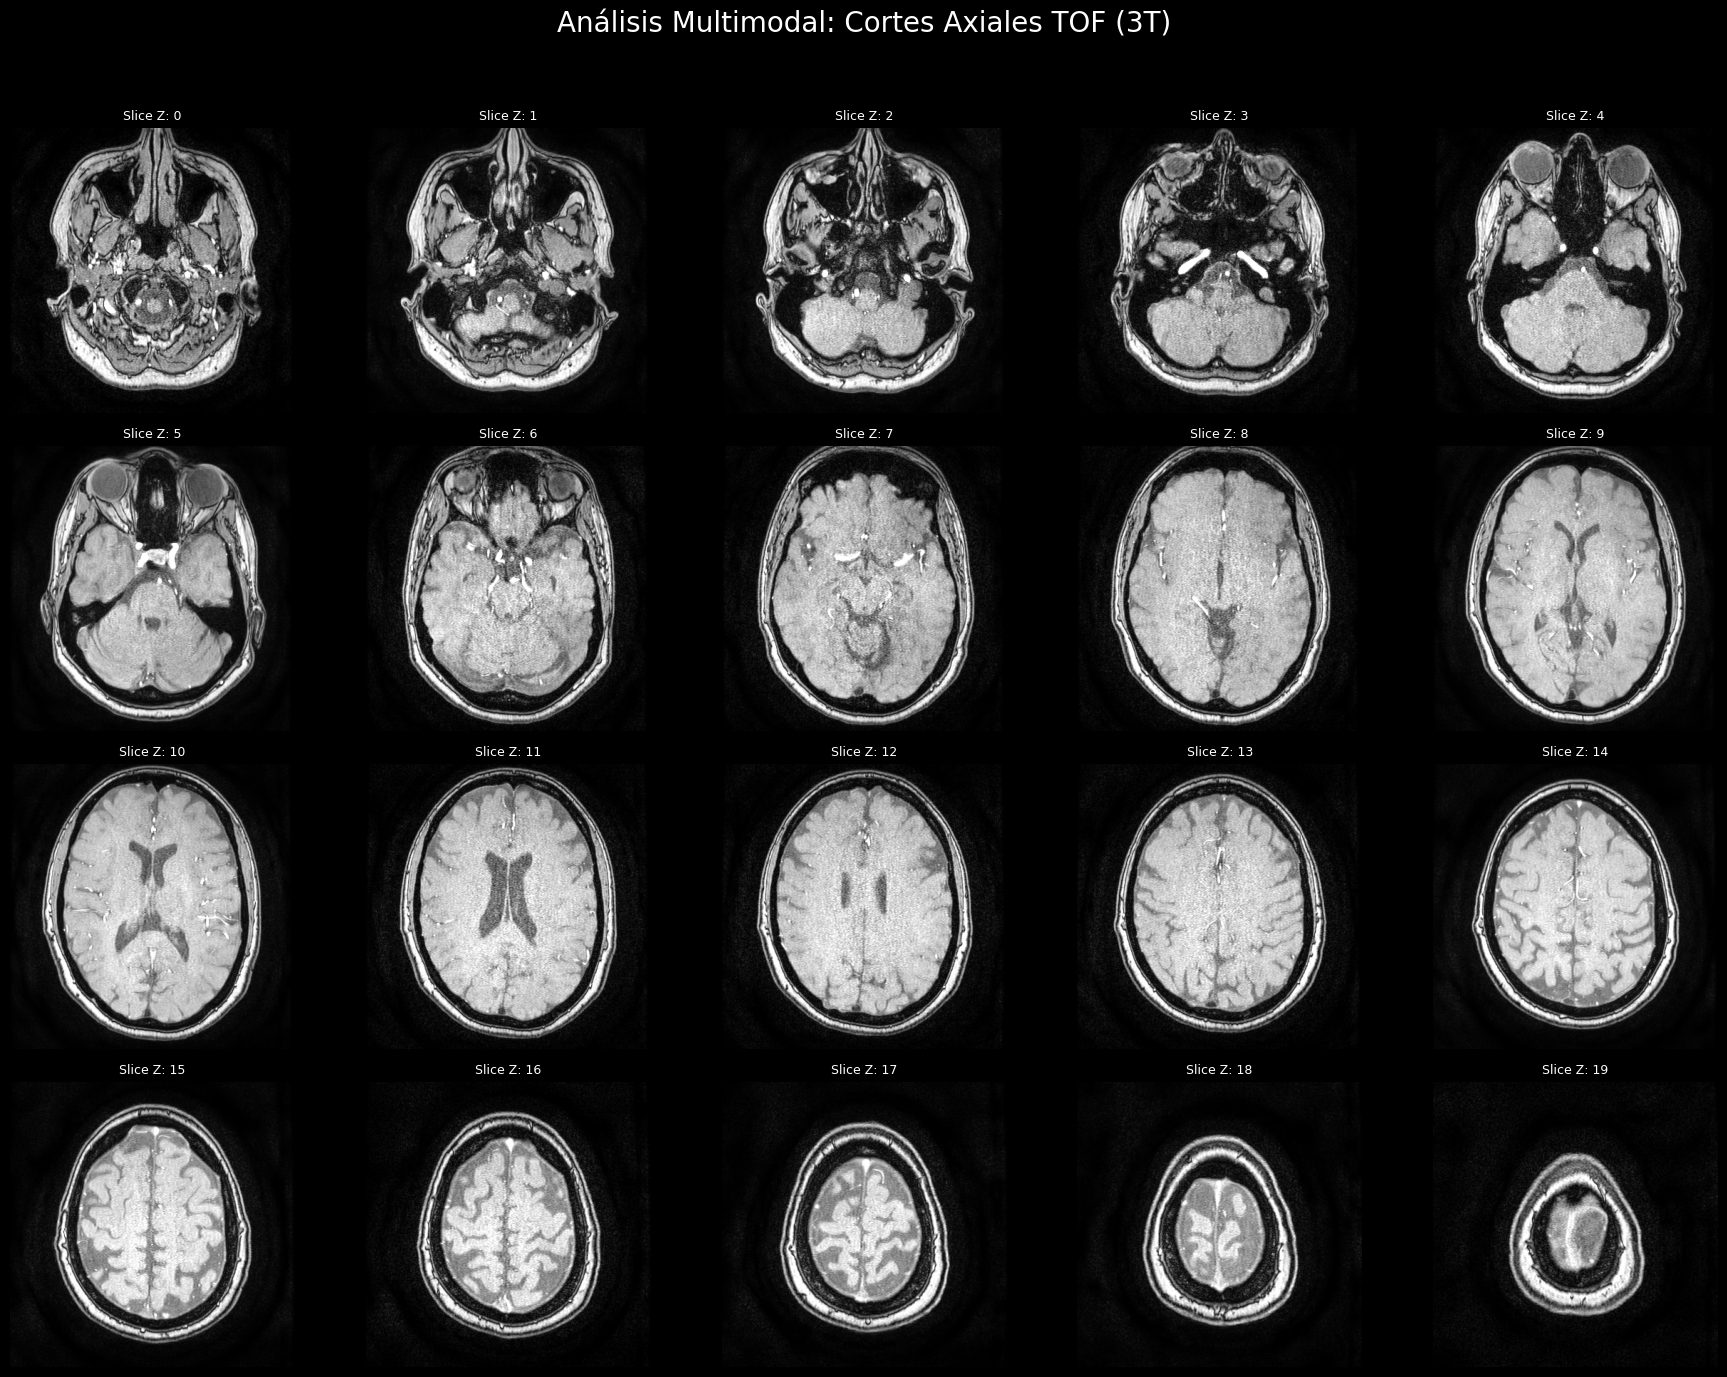

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

indices = np.linspace(0, volumen.shape[0] - 1, 20, dtype=int)

fig, axes = plt.subplots(4, 5, figsize=(18, 14), facecolor='black')
fig.suptitle('Análisis Multimodal: Cortes Axiales TOF (3T)', color='white', fontsize=20)

# i es el contador secuencial (0, 1, 2...), idx es el corte real (e.g., 0, 5, 10...)
for i, ax in enumerate(axes.flat):

    # Usamos idx para extraer la imagen (para que se vean distintas)
    idx = indices[i]

    if idx < volumen.shape[0]:
        slice_data = volumen[idx]

        # Mantener normalización para buen contraste
        v_min, v_max = np.percentile(slice_data, [1, 99])
        ax.imshow(slice_data, cmap='gray', vmin=v_min, vmax=v_max)

        ax.set_title(f'Slice Z: {i}', color='white', fontsize=9)

    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Parte C: Reconstrucción (MIP)**

En este paso, transformamos píxeles en fenotipos. Aplicamos un umbral estadístico (basado en la desviación estándar $\sigma$) para limpiar el ruido del fondo

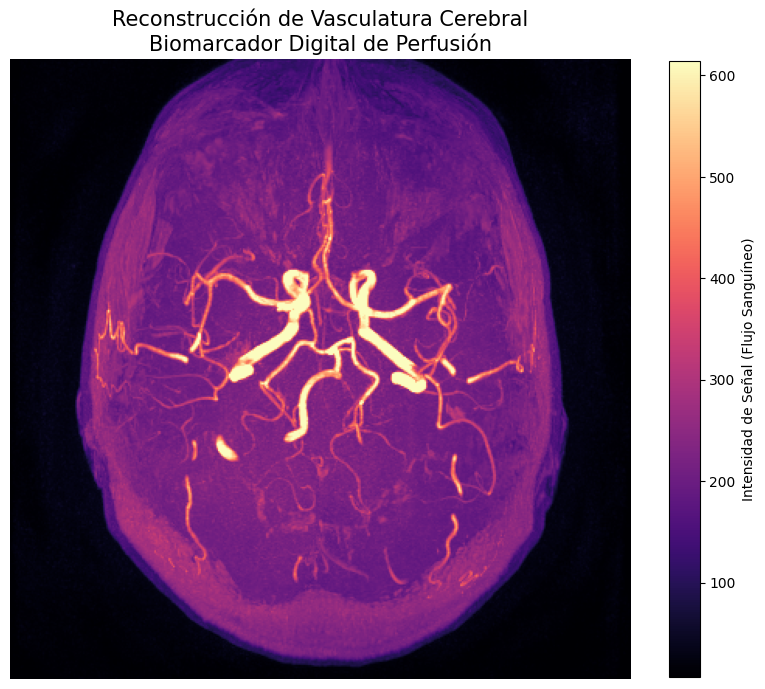

In [ ]:
# Generamos la proyección de máxima intensidad (MIP)
mip_axial = np.max(volumen, axis=0)

# Aplicamos un realce de contraste basado en percentiles para limpiar el ruido
# Esto ayuda a separar la vasculatura del parénquima
vmin, vmax = np.percentile(mip_axial, (1, 99))

plt.figure(figsize=(10, 10))
plt.imshow(mip_axial, cmap='magma', vmin=vmin, vmax=vmax)
plt.title('Reconstrucción de Vasculatura Cerebral\nBiomarcador Digital de Perfusión', fontsize=15)
plt.axis('off')
plt.colorbar(shrink=0.8, label='Intensidad de Señal (Flujo Sanguíneo)')
plt.show()

# **⚠️ Nota Importante: Uso Educativo y Limitaciones Técnicas**

Este módulo forma parte del pipeline práctico para comprender **la Hemodinámica Cerebral**. Es fundamental considerar las siguientes precisiones técnicas antes de proceder:

* **Diagnóstico Médico:** Los algoritmos de realce y proyección de máxima intensidad (MIP) pueden ocultar pequeñas estenosis o artefactos de flujo. Nunca deben utilizarse estas imágenes procesadas para diagnósticos médicos definitivos o planificación quirúrgica.
* **Naturaleza del Procesamiento:** La visualización aquí generada es una representación matemática de la intensidad de señal de un equipo Philips Insignia 3T. La segmentación de vasos depende de parámetros de umbralización que pueden variar según el ruido de la imagen.
* **Representación Hemodinámica:** La señal TOF es un biomarcador indirecto basado en la velocidad del flujo sanguíneo. Cambios en la presión intracraneal o en la viscosidad de la sangre, comunes en gliomas de alto grado, pueden alterar la fidelidad de la reconstrucción